In [107]:
import sys
import os
import numpy as np
from scipy import stats
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from LSM.stochastic_processes import GeometricBrownianMotion
from LSM.payoffs import VanillaPayoff
from LSM.regression_bases import LaguerrePolynomials
from LSM.algorithms import LeastSquaresMonteCarlo
from LSM.binomial_tree import BinomialTreeEngine
from LSM.control_variate import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
#(1) BSM Benchmark: Black-Scholes-Merton Model for European Options
def BSM(S0: float, K: float, T: float, r: float, q: float, sigma: float, option_type: str) -> float:
    """
    Returns the BSM price estimation of a European Option
    """
    option_type = option_type.lower()
    if option_type not in ['call', 'put']:
        raise ValueError("option_type must be either 'call' or 'put'.")

    d1 = (np.log(S0/K) + (r - q + 0.5*(sigma**2))*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == 'put':
        price = np.exp(-r*T) * K * stats.norm.cdf(-d2) - np.exp(-q*T) * S0 * stats.norm.cdf(-d1)
    else:
        price = np.exp(-q*T) * S0 * stats.norm.cdf(d1) - np.exp(-r*T) * K * stats.norm.cdf(d2)
    
    std = None

    return price, std

In [62]:
# Sanity check: an American call without dividend (q=0) is equivalent to a 
# European call. Compare our LSM price with the BSM European call price.
# Accuracy, runtime, (memory storage)

# Sample test parameters
S0 = 36
K = 40
r = 0.06
q = 0.0
sigma = 0.2
T = 1.0
n_steps = 50
n_paths = 10000

# BSM Sanity Check: (American Call Option = European Call)
start_bsm = time.time()
bsm_call = BSM(S0, K, T, r, q, sigma, option_type = "call")[0]
end_bsm = time.time()
print(f"BSM European Call Price: {bsm_call}.")

# American Call option price from Binomial Tree
start_BioTree = time.time()
call_payoff = VanillaPayoff(strike=K, option_type="call")
Binomial_eng = BinomialTreeEngine(call_payoff)
Binomial_call = Binomial_eng.pricer(S0=S0, r=r, q=q, sigma=sigma, T=T, n_steps=n_steps, american=True)
end_BioTree = time.time()
print(f"BinomialTree American Call Price {Binomial_call}")

gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
laguerre_basis = LaguerrePolynomials(degree=3)

lsm_eng = LeastSquaresMonteCarlo(
    process = gbm,
    payoff_function = call_payoff,
    basis_function=laguerre_basis
    )
start_lsm = time.time()
lsm_call = lsm_eng.pricer(T = T, n_steps = n_steps, n_paths = n_paths)[0]
end_lsm = time.time()
print(f"LSM American Call Price {lsm_call}.")
print(f"Absolute Error between BSM and LSM on Call: {abs(bsm_call - lsm_call)}")

print(f"BSM Runtime: {end_bsm - start_bsm}")
print(f"BinomialTree Runtime: {end_BioTree - start_BioTree}")
print(f"LSM Runtime: {end_lsm - start_lsm}")

BSM European Call Price: 2.1737264482268923.
BinomialTree American Call Price 2.1690295200457497
LSM American Call Price 2.208377537097433.
Absolute Error between BSM and LSM on Call: 0.03465108887054047
BSM Runtime: 0.0002460479736328125
BinomialTree Runtime: 0.000982046127319336
LSM Runtime: 0.13425731658935547


In [63]:
# TODO: Use the American put numerical example in Longstaff, Schartz (2001) pp. 126-128.
# Goals: 
# a) replicate their results; 
# b) compare with other benchmarks and libraries (e.g. CRR Binomial Tree),
# focusing on accuracy (prices), speed (%timeit) and memory usage
# [CREATE TESTS USING OTHER LIBRARIES FIRST!]


S0 = 36.0
r = 0.06
q = 0.0
sigma = 0.2
K = 40.0
T = 1.0
n_steps = 50
n_paths = 10000


gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
put_payoff = VanillaPayoff(strike=K, option_type="put") # "put"
laguerre_basis = LaguerrePolynomials(degree=3)


lsm_engine = LeastSquaresMonteCarlo(
    process=gbm, 
    payoff_function=put_payoff, 
    basis_function=laguerre_basis
)


time_grid, paths = gbm.simulate(T=T, n_steps=n_steps, n_paths=n_paths)
print(f"1. GBM paths shape: {paths.shape}  --> Expect ({n_paths}, {n_steps + 1})")

payoff_at_maturity = put_payoff(paths[:, -1])
print(f"2. Payoff shape: {payoff_at_maturity.shape}  --> Expect: ({n_paths},)")

test_X = paths[:100, -1]
test_Y = payoff_at_maturity[:100]
beta = laguerre_basis.fit(X=test_X, Y=test_Y)
print(f"3. beta fitted on Laguerre basis \n{beta}  --> Expect: ")


price = lsm_engine.pricer(T=T, n_steps=n_steps, n_paths=n_paths)
print(f"4. LSM price: {price}  --> Expect: ")

1. GBM paths shape: (10000, 51)  --> Expect (10000, 51)
2. Payoff shape: (10000,)  --> Expect: (10000,)
3. beta fitted on Laguerre basis 
[7.41095909e+01 3.45552688e+00 1.01737656e-01 1.31676146e-03]  --> Expect: 
4. LSM price: (4.491369137606416, 0.03035371174232816)  --> Expect: 


In [64]:
def LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put', control_type=None):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)


    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm, 
        payoff_function=put_payoff, 
        basis_function=laguerre_basis
    )

    
    price, std = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=None,
        use_antithetic=False,
        control_variate=control_type,
        cache=False
    )

    return price,std

In [65]:
def LSM_CV(S0, K, T, r, q, sigma, n_steps, n_paths, degree, 
           option_type='put', 
           control_type = 'european_at_maturity'):
    gbm = GeometricBrownianMotion(S0=S0, r=r, q=q, sigma=sigma)
    put_payoff = VanillaPayoff(strike=K, option_type=option_type)
    laguerre_basis = LaguerrePolynomials(degree=degree)
    
    lsm_engine = LeastSquaresMonteCarlo(
        process=gbm, 
        payoff_function=put_payoff, 
        basis_function=laguerre_basis)

    price_cv, std_cv = lsm_engine.pricer(
        T=T,
        n_steps=n_steps,
        n_paths=n_paths,
        rng=np.random.default_rng(42),
        use_antithetic=False,
        control_variate=control_type,
        cache=False
    )

    return price_cv, std_cv

In [66]:
#(3) Binomial Tree Benchmark:
def BTM(S0, K, T, r, q, sigma, n_steps, option_type = 'put'):
    payoff = VanillaPayoff(strike=K, option_type=option_type)
    Binomial_eng = BinomialTreeEngine(payoff)
    Binomial_price = Binomial_eng.pricer(S0=S0, r=r, q=q, sigma=sigma, T=T, n_steps=n_steps, american=True)
    std = None
    return Binomial_price, std

In [67]:
#(4) Finite Difference Benchmark: 
# Import the existed Package of Finite Difference Method from QuantLib
import QuantLib as ql

def FDM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = "put"):
    """
    Utilize Finite-Difference Method to estimate the price of American Put Option
    FDM is directly imported from QuantLib
    """
    # Time Setting (today, expiry)
    TD = ql.Date.todaysDate()
    ql.Settings.instance().evaluationDate = TD
    expiry = TD + ql.Period(int(T * 365), ql.Days)

    # Market Information
    spot = ql.QuoteHandle(ql.SimpleQuote(S0))
    inv = ql.YieldTermStructureHandle(ql.FlatForward(TD, r, ql.Actual365Fixed())) # risk-free rate
    div = ql.YieldTermStructureHandle(ql.FlatForward(TD, q, ql.Actual365Fixed())) # dividend rate
    vol = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(TD, ql.NullCalendar(), sigma, ql.Actual365Fixed()))

    # Black-Scholes-Merton Model
    bsm = ql.BlackScholesMertonProcess(spot, div, inv, vol)

    # Option Set-up
    if option_type.lower() == 'put':
        cp = ql.Option.Put
    else:
        cp = ql.Option.Call
    payoff = ql.PlainVanillaPayoff(cp, K)
    exercise = ql.AmericanExercise(TD, expiry)
    option = ql.VanillaOption(payoff, exercise)

    # Crank-Nicolson Finite-Difference Method
    fdm = ql.FdBlackScholesVanillaEngine(
        bsm,
        n_steps,
        n_paths
    )
    option.setPricingEngine(fdm)
    price = option.NPV()
    stdev = None #Note FDM has an analytical formula of pricing.


    return price, stdev


In [68]:
#(4) Comparison Table for LSM Accuracy and RunTime （需要验证）
# Assume here it is always American Put Option
# The Benchmark must be the estimated price by a highly stable and accurate model,
    #i.e., Binominal Tree Method

def comparison(model, name: str, benchmark_price, **kwargs):
    """
    Take all existed models (BSM, LSM, ...) to compute prices
    Compare Accuracy and RunTime of our LSM with other models
    Return a Comparison Table
    """

    start = time.time()
    price,std = model(**kwargs)
    end = time.time()

    runtime = end - start
    abs_error = abs(price - benchmark_price)
    #rel_error = abs_error / benchmark_price

    Ctable = {
        "Model": name,
        "Price": price,
        "std": std,
        "Absolute Error": abs_error,
        "RunTime": runtime
    }

    return Ctable
 


In [69]:
#Parameters 
cargs = dict(S0=S0, K=K, T=T, r=r, q=q, sigma=sigma, option_type = 'put')

#Benchmark
benchmark_price, _ = BTM(S0=S0, K=K, T=T, r=r, q=q, sigma=sigma, n_steps=n_steps, option_type='put')
print(benchmark_price)

#Realization of Comparison Table
models = []

models.append(
    comparison(LSM, "Least Square Monte Carlo", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3,
               control_type = None))
models.append(
    comparison(LSM_CV, "LSM + Control Variate at maturity", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3, 
               control_type = 'european_at_maturity'))
models.append(
    comparison(LSM_CV, "LSM + Control Variate at excercise", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths, degree=3, 
               control_type = 'european_at_exercise'))
models.append(
    comparison(BTM, "Binomial Tree Model", benchmark_price, **cargs, n_steps=n_steps))
models.append(
    comparison(FDM, "Finite Difference Method", benchmark_price, **cargs, n_steps=n_steps, n_paths=n_paths))
models.append(
    comparison(BSM, "Black Scholes Model", benchmark_price, **cargs)
)

#Convert into a Data Frame
df = pd.DataFrame(models)

print(df)

4.4844980628541835
                                Model     Price       std  Absolute Error  \
0            Least Square Monte Carlo  4.492486  0.029453        0.007988   
1   LSM + Control Variate at maturity  4.486759  0.024271        0.002261   
2  LSM + Control Variate at excercise  4.471446  0.002139        0.013052   
3                 Binomial Tree Model  4.484498       NaN        0.000000   
4            Finite Difference Method  4.477558       NaN        0.006940   
5                 Black Scholes Model  3.844308       NaN        0.640190   

    RunTime  
0  0.225052  
1  0.150219  
2  0.215597  
3  0.000411  
4  0.044342  
5  0.000166  


In [70]:
# (Part 1) Sanity Check: Paper Table 1 Replication & Comparison our LSM engine vs. Longstaff-Schwartz Paper Result
# Parameters: (fixed) K, r, q, n_steps, n_paths; S0, sigma, T (change in order)
fixed_param = {
    "K": 40,
    "r": 0.06,
    "q": 0.0,
    "n_steps": 50,
    "n_paths": 50000 #Note the paper uses 100,000 paths, but we make it 50,000 to reduce the time, could be raised after.
}

S0_list = [36, 38, 40, 42, 44]
sigma_list = [0.20, 0.40]
Time_list = [1, 2]


# Results from Table 1 (American Put Option Price by FDM)
FDM_Table1 = {
    (36, 0.20, 1): 4.478, (36, 0.20, 2): 4.840,
    (36, 0.40, 1): 7.101, (36, 0.40, 2): 8.508,
    (38, 0.20, 1): 3.250, (38, 0.20, 2): 3.745,
    (38, 0.40, 1): 6.148, (38, 0.40, 2): 7.670,
    (40, 0.20, 1): 2.314, (40, 0.20, 2): 2.885,
    (40, 0.40, 1): 5.312, (40, 0.40, 2): 6.920,
    (42, 0.20, 1): 1.617, (42, 0.20, 2): 2.212,
    (42, 0.40, 1): 4.582, (42, 0.40, 2): 6.248,
    (44, 0.20, 1): 1.110, (44, 0.20, 2): 1.690,
    (44, 0.40, 1): 3.948, (44, 0.40, 2): 5.647,
}

# Results from Table 1 (American Put Option Price by LSM)
LSM_Table1 = {
    (36, 0.20, 1): (4.472, 0.010), (36, 0.20, 2): (4.821, 0.012),
    (36, 0.40, 1): (7.091, 0.020), (36, 0.40, 2): (8.488, 0.024),
    (38, 0.20, 1): (3.244, 0.009), (38, 0.20, 2): (3.735, 0.011),
    (38, 0.40, 1): (6.139, 0.019), (38, 0.40, 2): (7.669, 0.022),
    (40, 0.20, 1): (2.313, 0.019), (40, 0.20, 2): (2.879, 0.010),
    (40, 0.40, 1): (5.308, 0.018), (40, 0.40, 2): (6.921, 0.022),
    (42, 0.20, 1): (1.617, 0.007), (42, 0.20, 2): (2.206, 0.010),
    (42, 0.40, 1): (4.588, 0.017), (42, 0.40, 2): (6.243, 0.021),
    (44, 0.20, 1): (1.118, 0.007), (44, 0.20, 2): (1.675, 0.009),
    (44, 0.40, 1): (3.957, 0.017), (44, 0.40, 2): (5.622, 0.021), 
}

# Table 1 Replication using our own LSM engine
def table1_replication(LSM_engine, FDM_engine, iterations = 25, seed = 42):
    """
    Here we test our own LSM engine to replicate Table 1 from LongStaff-Schwartz Paper by iterations times,
        take "average price, standard deviation" and compare with Table 1 from paper
    Fix Seed at 42
    Input:
        LSM_engine: our own implementation of LSM algorithm
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, degree, option_type='put')
        FDM_engine: the imported FDM algorithm from QuantLib
             FDM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = "put")
        iterations: as it states, the iteration times to reduce randomness
        seed: randomness
    Return:
        dataframe: a DataFrame with the same format of Paper Table 1
    """
    # fixed parameters
    K = fixed_param["K"]
    r = fixed_param["r"]
    q = fixed_param["q"]
    n_steps = fixed_param["n_steps"]
    n_paths = fixed_param["n_paths"]
    # storage list
    results = [] # Replication Table 1
    comparison = [] # Comparison Table

    # simulation
    for S0 in S0_list:
        for sigma in sigma_list:
            for T in Time_list:
                N_steps = n_steps * T
                feature = (S0, sigma, T)

                # LSM engine iterations
                lsm_prices = []
                lsm_std = []
                for i in range(iterations):
                    np.random.seed(seed + i)
                    price, std = LSM_engine(
                        S0 = S0, K = K, T = T, r = r, q = q, 
                        sigma = sigma, degree = 3, n_steps = N_steps, n_paths = n_paths)
                    lsm_prices.append(price)
                    lsm_std.append(std)

                lsm_price = np.mean(lsm_prices)
                lsm_se = np.mean(lsm_std)

                # FDM engine iterations 
                fdm_price, _ = FDM_engine(
                    S0 = S0, K = K, T = T, r = r, q = q,
                    sigma = sigma, n_steps = 100, n_paths = 400)

                # BSM European Put Option Price
                BSM_price, _ = BSM(S0, K, T, r, q, sigma, option_type = "put")

                # Early Exercise Value: AmericanPut - EuropeanPut
                fdm_early_val = fdm_price - BSM_price
                lsm_early_val = lsm_price - BSM_price

                paper_lsm_val, paper_lsm_se = LSM_Table1[feature]

                # Accuracy Comparison
                diff_price_val = lsm_price - fdm_price
                diff_early_val =  lsm_early_val - fdm_early_val
                within_2se = abs(diff_price_val) <= 2 * lsm_se

                results.append({
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    #FDM vals
                    "Finite Difference American": fdm_price,
                    "Closed form European": BSM_price,
                    "Early exercise Value (FDM)": fdm_early_val,
                    #LSM simulated vals
                    "Simulated American": lsm_price,
                    "(s.e.)": lsm_std,
                    "Closed form European": BSM_price,
                    "Early exercise Value (LSM)": lsm_early_val,
                    # Difference between two methods
                    "Difference in early exercise value": diff_early_val
                })

                comparison.append({
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    # FDM benchmark
                    "FDM Price": round(fdm_price, 3),
                    "FDM early exercise": round(fdm_early_val, 3),
                    # LSM engine
                    "LSM Price": round(lsm_price, 3),
                    "LSM s.e.": round(lsm_se, 3),
                    "LSM early exercise": round(lsm_early_val, 3),
                    # Paper LSM
                    "Paper LSM": paper_lsm_val,
                    "Paper s.e.": paper_lsm_se,
                    # Accuracy
                    "Difference in Vals": diff_price_val,
                    "Difference in Early Exercise": diff_early_val,
                    "Whether within 2 s.e.": "yes" if within_2se else "no"
                })
    return pd.DataFrame(comparison)
                    
# generate Comparison Table between our replication and original Table 1
if __name__ == "__main__":
    import time

    start = time.time()
    dataframe = table1_replication(LSM, FDM, iterations = 25)
    elapsed = time.time() - start

    print(f"Runtime: {elapsed:.1f}s")
    print("\n---------------- Table 1 Replication Comparison ----------------")
    print(dataframe.to_string(index = False))

    print("\n---------------- Summary ----------------")
    print(f"Mean |Difference in Vals|: {dataframe['Difference in Vals'].abs().mean():.4f}")
    print(f"Max |Difference in Vals|: {dataframe['Difference in Vals'].abs().max():.4f}")
    within = (dataframe["Whether within 2 s.e."] == 'yes').sum()
    print(f"Whether within 2 s.e.: {within}/{len(dataframe)}")
    print(f"|accuracy| < 0.03: {(dataframe['Difference in Vals'].abs() < 0.03).sum()}/{len(dataframe)}")

    dataframe.to_csv("Table1_replication_comparison.csv", index = False)

Runtime: 176.5s

---------------- Table 1 Replication Comparison ----------------
 S0  sigma  T  FDM Price  FDM early exercise  LSM Price  LSM s.e.  LSM early exercise  Paper LSM  Paper s.e.  Difference in Vals  Difference in Early Exercise Whether within 2 s.e.
 36    0.2  1      4.482               0.638      4.480     0.013               0.636      4.472       0.010           -0.002258                     -0.002258                   yes
 36    0.2  2      4.840               1.077      4.844     0.016               1.081      4.821       0.012            0.003901                      0.003901                   yes
 36    0.4  1      7.105               0.394      7.096     0.027               0.385      7.091       0.020           -0.009312                     -0.009312                   yes
 36    0.4  2      8.507               0.807      8.512     0.032               0.812      8.488       0.024            0.004487                      0.004487                   yes
 38    0.2  1

In [71]:
#(Part 2) Random Paramter Sampling (note n_paths = 10000 here)
def random_benchmark_test(LSM_engine, FDM_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we run random parameter sampling benchmark on our LSM engine
        Compare LSM versus FDM across all randomly generated parameters (with K fixed at 100)
    Input:
        LSM_engine: our own implementation of LSM algorithm
            LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type='put')
        FDM_engine: the imported FDM algorithm from QuantLib as comparison
            FDM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = "put")
        iterations: as it states, the iteration times to reduce randomness
        parameters: S0, K, T, r, q, sigma, (n_steps, n_paths)
    Return:
        dataframe: a DataFrame similar to Table 1
    """
    # Parameters
    np.random.seed(seed)
    strike = 100 # We fix K at 100 for convenience (ITM, ATM, OTM)
    stock = np.random.uniform(60, 140, n_samples) # from deep ITM to deep OTM
    volatility = np.random.uniform(0.050, 0.60, n_samples)
    duration = np.random.uniform(0.25, 3.0, n_samples)
    interest = np.random.uniform(0.01, 0.15, n_samples)
    dividend = np.random.uniform(0.00, 0.08, n_samples)

    results = []

    for indx in range(n_samples):
        n_steps = int(50 * duration[indx])
        S0 = round(stock[indx], 3)
        K = strike
        sigma = round(volatility[indx], 4)
        T = round(duration[indx], 4)
        r = round(interest[indx], 4)
        q = round(dividend[indx], 4)

        # LSM Iterations
        lsm_prices = []
        lsm_std = []
        for i in range(iterations):
            np.random.seed(seed*100 + indx*10 + i)
            price, std = LSM_engine(
                S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000)
            lsm_prices.append(price)
            lsm_std.append(std)
        
        lsm_price = np.mean(lsm_prices)
        lsm_se = np.mean(lsm_std)

        # FDM Iterations
        fdm_price, _ = FDM_engine(
            S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
            sigma = sigma, n_steps = 200, n_paths = 400)
        
        # BSM on European Options
        bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type = option_type)

        accuracy = lsm_price - fdm_price
        if lsm_se > 1e-6:
            within_2se = abs(accuracy) <= 2*lsm_se
        else:
            within_2se = abs(accuracy) < 0.001 # LSM std error close to zero but LSM price within a tenth of a cent of the FDM price
        dist_se = abs(accuracy)/(lsm_se + 1e-6)
        within_2se = abs(accuracy) <= (2*lsm_se)
        # if S0/K < 1:
        #     moneyness = "ITM"
        # elif S0/K == 1:
        #     moneyness = "ATM"
        # else:
        #     moneyness = "OTM"
        moneyness = round(S0 / K , 3)

        results.append({
            "S0": S0,
            "K": K,
            "sigma": sigma,
            "T": T,
            "r": r,
            "q": q,
            "Moneyness": moneyness,
            "FDM price": round(fdm_price, 3),
            "LSM price": round(lsm_price, 3),
            "LSM s.e.": round(lsm_se, 4),
            "BSM price": round(bsm_price, 3),
            "Early Exercise (FDM)": round(fdm_price - bsm_price, 4),
            "Early Exercise (LSM)": round(lsm_price - bsm_price, 4),
            "Accuracy": round(accuracy, 3),
            "Distance to se": round(dist_se, 3),
            "Within 2se": "yes" if within_2se else "no"
        })

        if (indx + 1) % 20 == 0:
            print(f" {indx+1} / {n_samples} done...")

    results = pd.DataFrame(results)
    if option_type == 'put':
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['ITM (Put)', 'ATM', 'OTM (Put)'])
    else:
        results['Moneyness_Bucket'] = pd.cut(results['Moneyness'], 
                                             bins=[0, 0.9, 1.1, 2.0], 
                                            labels=['OTM (Call)', 'ATM', 'ITM (Call)'])

    return results.sort_values(by=['Moneyness', 'T'], ascending=[False, False])
    


# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    df = random_benchmark_test(LSM, FDM, option_type = 'put', n_samples = 200, iterations = 25, seed = 42)
    elapsed = time.time() - start

    print(f"\n Total Cases: {len(df)}")
    print(f"Runtime: {elapsed:.1f}s")
    print(f"Mean |Accuracy|: {df['Accuracy'].abs().mean():.4f}")
    print(f"Max |Accuracy|: {df['Accuracy'].abs().max():.4f}")
    within = (df['Within 2se'] == 'yes').sum()
    print(f"within 2 s.e.: {within}/{len(df)}")
    small = (df["Accuracy"].abs() < 0.05).sum()
    print(f"|Accuracy| < 0.05: {small}/{len(df)}")

    df.to_csv("random_benchmark_test.csv", index = False)

    summary = df.groupby('Moneyness_Bucket', observed=False).agg({
        'Accuracy': ['mean', 'std'],
        'Within 2se': lambda x: (x == 'yes').mean()
    })
    print("\n", summary)

 20 / 200 done...
 40 / 200 done...


/var/folders/82/rf2s730x5_18hmy0md9pyghw0000gp/T/ipykernel_9026/4105787270.py:63: RuntimeWarning: divide by zero encountered in scalar divide
  dist_se = abs(accuracy)/(lsm_se)


 60 / 200 done...
 80 / 200 done...
 100 / 200 done...
 120 / 200 done...
 140 / 200 done...
 160 / 200 done...
 180 / 200 done...
 200 / 200 done...

 Total Cases: 200
Runtime: 642.3s
Mean |Accuracy|: 0.0195
Max |Accuracy|: 0.1650
within 2 s.e.: 174/200
|Accuracy| < 0.05: 182/200

                   Accuracy           Within 2se
                      mean       std   <lambda>
Moneyness_Bucket                               
ITM (Put)         0.004773  0.033686   0.715909
ATM               0.012795  0.019312   0.974359
OTM (Put)         0.018178  0.020192   1.000000


In [72]:
#(Part 2) Random Parameter Sampling (Summary about the inaccurate cases)
df_sorted = df.sort_values("Accuracy", ascending=False)
print(df_sorted[["S0", "sigma", "T", "r", "q", 
                  "FDM price", "LSM price", "Accuracy", "Moneyness", "Moneyness_Bucket"]].head(10))

          S0   sigma       T       r       q  FDM price  LSM price  Accuracy  \
164   67.223  0.5678  1.2141  0.0147  0.0231     40.567     40.673     0.106   
124   78.235  0.5752  2.5554  0.0904  0.0340     35.256     35.361     0.105   
190   67.448  0.5948  0.6318  0.0315  0.0640     37.182     37.255     0.073   
121  131.687  0.4430  1.2974  0.0354  0.0390     10.189     10.260     0.071   
113  124.650  0.5795  2.6317  0.0677  0.0328     23.764     23.835     0.071   
141   80.143  0.3104  1.9170  0.0522  0.0443     25.123     25.190     0.067   
45   113.002  0.5606  2.8549  0.1347  0.0332     20.533     20.598     0.065   
42    62.751  0.5532  1.2792  0.0396  0.0142     41.463     41.528     0.065   
80   129.048  0.5395  1.9808  0.1244  0.0185     13.629     13.694     0.064   
73   125.237  0.5523  2.7006  0.0834  0.0327     20.966     21.028     0.061   

     Moneyness Moneyness_Bucket  
164      0.672        ITM (Put)  
124      0.782        ITM (Put)  
190      0.674   

In [73]:
#(Part 3) Moneyness Testing - Compare Accuracy across ITM, ATM, OTM options
def moneyness_test(df_random):
    """
    Extract ATM/ITM/OTM cases from the results of (Part 2) random benchmark test
    Show the early exercise premium across moneyness levels
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        summary: a summary of accuracy across moneyness
    """
    # Group by moneyness for 
    def classify(m):
        if m < 0.75:
            return "Deep ITM"
        elif 0.75 <= m < 0.90:
            return "ITM"
        elif 0.90 <= m < 0.98:
            return "Slight ITM"
        elif 0.98 <= m <= 1.02:
            return "ATM"
        elif 1.02 < m <= 1.10:
            return "Slight OTM"
        elif 1.10 < m <= 1.25:
            return "OTM"
        else:
            return "Deep OTM"
        
    df = df_random.copy()
    df["Moneyness Level"] = (df["S0"] / 100).apply(classify) # We already fix K at 100

    # Group by moneyness level and summarize accuracy
    summary = df.groupby("Moneyness Level").agg(
        Count = ("LSM price", "count"),
        LSM_mean = ("LSM price", "mean"),
        FDM_mean = ("FDM price", "mean"),
        EarlyEx_mean = ("Early Exercise (LSM)", "mean"),
        EarlyEx_max = ("Early Exercise (LSM)", "max"),
        EarlyEx_min = ("Early Exercise (LSM)", "min"),
        Accuracy_mean = ("Accuracy", "mean"),
        Accuracy_std = ("Accuracy", "std"),
        Accuracy_max = ("Accuracy", "max"),
        Within_2se = ("Within 2se", lambda x: (x == 'yes').sum())
    ).round(4)

    order = ["Deep ITM", "ITM", "Slight ITM", "ATM", "Slight OTM", "OTM", "Deep OTM"]
    summary = summary.reindex(o for o in order if o in summary.index)

    return df, summary

if __name__ == "__main__":
    # We already have df from the random benchmark test, we can directly run the moneyness test
    df_detail, df_summary = moneyness_test(df)

    print("\n---------------- Moneyness Test Summary ----------------")
    print(df_summary.to_string())

    df_summary.to_csv("moneyness_test_summary.csv")
    df_detail.to_csv("moneyness_test_detail.csv", index = False)


---------------- Moneyness Test Summary ----------------
                 Count  LSM_mean  FDM_mean  EarlyEx_mean  EarlyEx_max  EarlyEx_min  Accuracy_mean  Accuracy_std  Accuracy_max  Within_2se
Moneyness Level                                                                                                                          
Deep ITM            43   33.6218   33.6128        5.9198      18.1120      -0.0481         0.0089        0.0273         0.106          25
ITM                 45   23.6174   23.6166        3.4403      13.7643      -0.1299         0.0008        0.0387         0.105          38
Slight ITM          10   13.9095   13.9001        1.9486       8.9775       0.1427         0.0094        0.0245         0.055           9
ATM                 13   15.4707   15.4541        1.0490       2.7839       0.0242         0.0164        0.0165         0.049          13
Slight OTM          16   10.7172   10.7049        0.2574       1.5405      -0.0400         0.0120        0.0186   

In [74]:
df_detail, df_summary = moneyness_test(df)
print((df_detail["S0"] / 100).describe())
print(df_detail["Moneyness Level"].value_counts())

count    200.000000
mean       0.987205
std        0.235913
min        0.604420
25%        0.782868
50%        0.995590
75%        1.205488
max        1.389510
Name: S0, dtype: float64
Moneyness Level
ITM           45
Deep ITM      43
Deep OTM      37
OTM           36
Slight OTM    16
ATM           13
Slight ITM    10
Name: count, dtype: int64


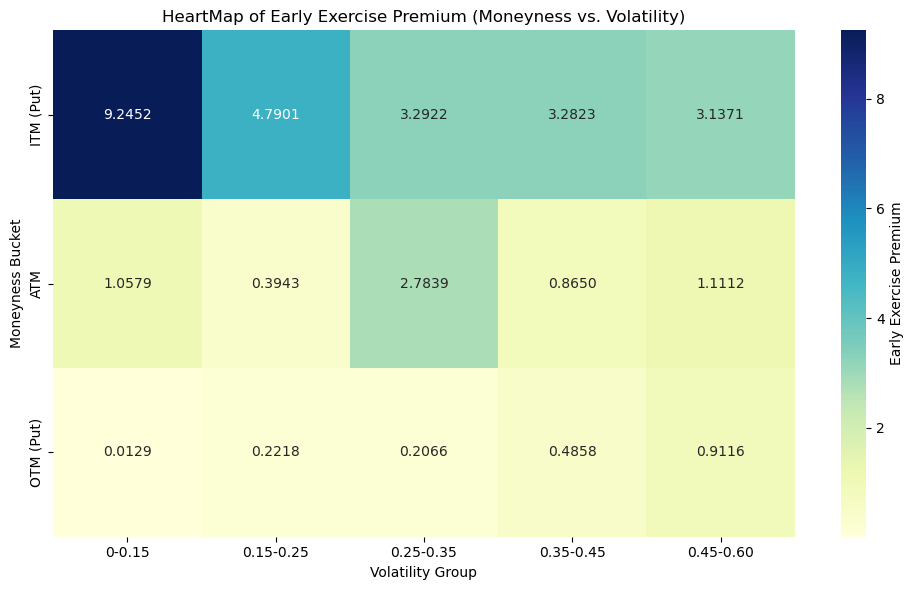

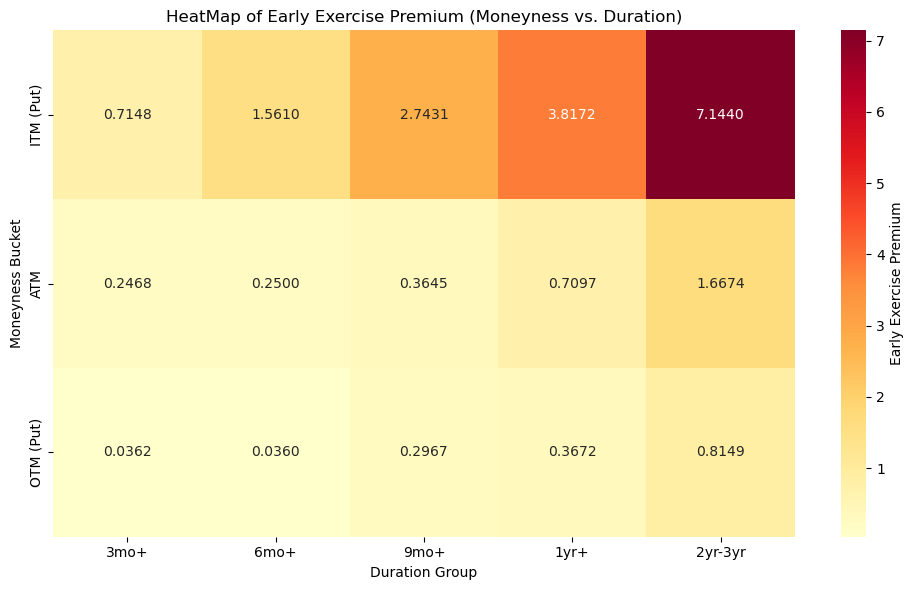

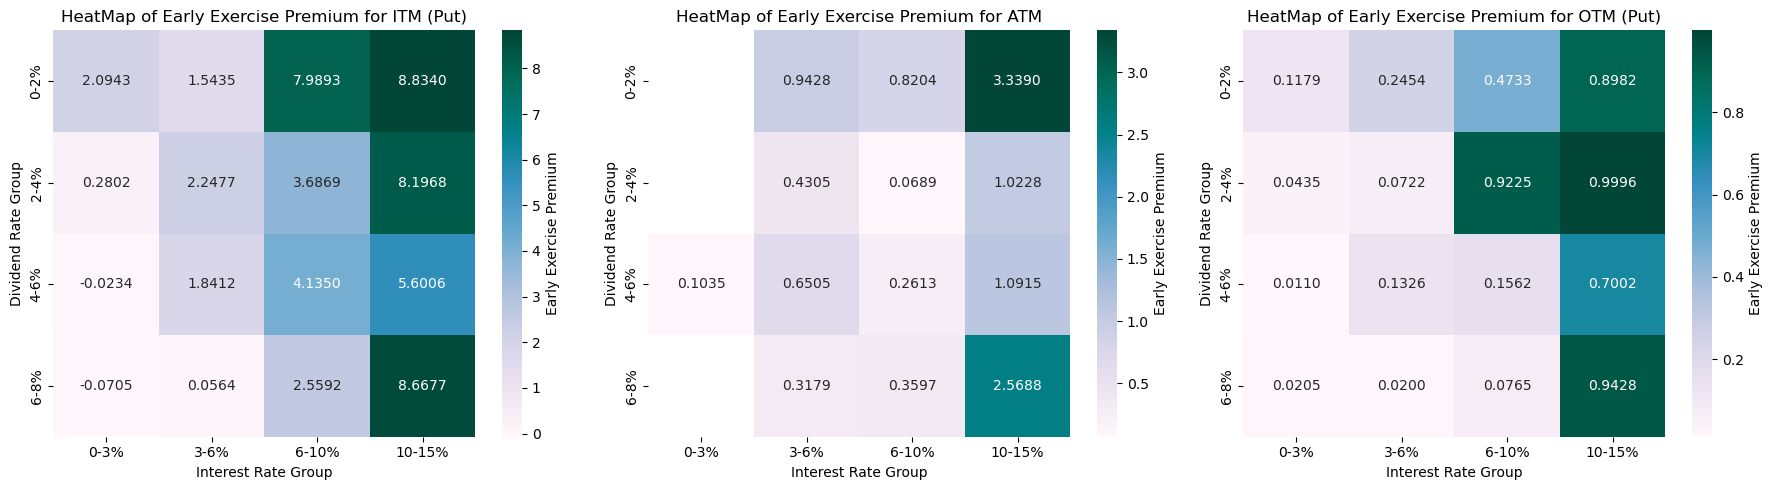

In [117]:
#(Part 4) Visualization of random benchmark test results - e.g. how the early exercise premium changes across moneyness and duration    
def moneyness_vol_heat_map(df):
    """
    Visualize how the early exercise premium changes across moneyness and volatility
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across moneyness and duration
    """
    df['Volatility_group'] = pd.cut(df['sigma'], bins=[0, 0.15, 0.25, 0.30, 0.45, 0.60], labels=['0-0.15', '0.15-0.25', '0.25-0.35', '0.35-0.45', '0.45-0.60'])
    heatmap_data = df.groupby(['Moneyness_Bucket', 'sigma_group'])['Early Exercise (LSM)'].mean().unstack()
    order = ["ITM (Put)", "ATM", "OTM (Put)"]
    heatmap_data = heatmap_data.reindex(order)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'Early Exercise Premium'})
    plt.title('HeartMap of Early Exercise Premium (Moneyness vs. Volatility)')
    plt.xlabel('Volatility Group')
    plt.ylabel('Moneyness Bucket')
    plt.tight_layout()
    plt.show()

def moneyness_duration_heat_map(df):
    """
    Visualize how the early exercise premium changes across moneyness and duration
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across moneyness and duration
    """
    df['Duration_group'] = pd.cut(df['T'], bins=[0.24, 0.5, 0.75, 1.0, 2.0, 3.0], labels=['3mo+', '6mo+', '9mo+', '1yr+', '2yr-3yr'])
    heatmap_data = df.groupby(['Moneyness_Bucket', 'T_group'])['Early Exercise (LSM)'].mean().unstack()
    order = ["ITM (Put)", "ATM", "OTM (Put)"]
    heatmap_data = heatmap_data.reindex(order)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlOrRd", cbar_kws={'label': 'Early Exercise Premium'})
    plt.title('HeatMap of Early Exercise Premium (Moneyness vs. Duration)')
    plt.xlabel('Duration Group')
    plt.ylabel('Moneyness Bucket')
    plt.tight_layout()
    plt.show()

def interest_divided_heat_map(df):
    """
    Visualize how the early exercise premium changes across interest rate and dividend rate
    Input:
        df: the DataFrame generated from random_benchmark_test function
    Return:
        a heat map of early exercise premium across interest rate and dividend rate
    """
    df['interest_group'] = pd.cut(df['r'], bins=[0.00, 0.03, 0.06, 0.10, 0.15], labels=['0-3%', '3-6%', '6-10%', '10-15%'])
    df['dividend_group'] = pd.cut(df['q'], bins=[0.00, 0.02, 0.04, 0.06, 0.08], labels=['0-2%', '2-4%', '4-6%', '6-8%'])
    order_r = ['0-3%', '3-6%', '6-10%', '10-15%']
    order_q = ['0-2%', '2-4%', '4-6%', '6-8%']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, bucket in zip(axes, ['ITM (Put)', 'ATM', 'OTM (Put)']):
        subset = df[df['Moneyness_Bucket'] == bucket]
        heatmap_data = subset.groupby(['q_group', 'r_group'])['Early Exercise (LSM)'].mean().unstack()
        heatmap_data = heatmap_data.reindex(index=order_q, columns=order_r)
        sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="PuBuGn", cbar_kws={'label': 'Early Exercise Premium'}, ax=ax)
        ax.set_title(f'HeatMap of Early Exercise Premium for {bucket}')
        ax.set_xlabel('Interest Rate Group')
        ax.set_ylabel('Dividend Rate Group')
    plt.tight_layout()
    plt.show()
#Note that the problem with HeatMap of r vs. q could be due to the limited number of samples in each bucket, which leads to high variance in the average early exercise premium.
#We may fix this by increasing the sample size from 200 to 2000 but this causes a significant increase in runtime, so we keep it as it is for now and just interpret the heatmap with caution.
#Also, the white blocks in the heatmap for ATM case are because of the limited sample size as well - we don't have certain data generated

if __name__ == "__main__":
    moneyness_vol_heat_map(df)
    moneyness_duration_heat_map(df)
    interest_divided_heat_map(df)


In [ ]:
#(Part 5) Edge Cases Testing - Compare Accuracy across different parameters (e.g. very high volatility, very long duration, etc.)
def edge_case_test(LSM_engine, FDM_engine, option_type = 'put', n_samples = 200, iterations = 25, seed = 42):
    """
    Here we test the stability of LSM_engines with extreme paramters,
        and how extreme parameters affect the price of American Options estimated by our LSM engine
        and also how the early exercise premium changes 
        Note that for each paramter, we will fix other paramters for simplification.
    Inputs:
        LSM_engine: LSM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = 'put')
        FDM_engine: FDM(S0, K, T, r, q, sigma, n_steps, n_paths, option_type = 'put')
        iterations: repeating times to reduce randomness
        parameters: S0, K, T, r, q, sigma, n_steps, n_paths, 'put'
    Returns:
        dataframe: a DataFrame summarizing the results of edge cases testing
            pair up high and low values for each parameter, and compare the price, early exercise premium, accuracy, etc.
    """
    np.random.seed(seed)
    K = 100

    edge_cases = {
        "Deep ITM, S0":{
            "fixed": {"sigma": 0.30, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"S0": (50, 70)}},
        "Deep OTM, S0": {
            "fixed": {"sigma": 0.30, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"S0": (130, 150)}},
        "Very High Volatility, sigma": {
            "fixed": {"S0": 80, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"sigma": (0.30, 0.50)}},
        "Very Low Volatility, sigma": {
            "fixed": {"S0": 80, "T": 1, "r": 0.05, "q": 0.02}, 
            "vary": {"sigma": (0.05, 0.15)}},
        "Very Long Duration, T": {
            "fixed": {"S0": 80, "sigma": 0.30, "r": 0.05, "q": 0.02},
            "vary": {"T": (3.0, 5.0)}},
        "Very Short Duration, T"   :{
            "fixed": {"S0": 80, "sigma": 0.30, "r": 0.05, "q": 0.02},
            "vary": {"T": (0.10, 0.25)}},
        "Very High Interest, r": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "q": 0.02},
            "vary": {"r": (0.10, 0.15)}},
        "Very Low Interest, r": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "q": 0.02},
            "vary": {"r": (0.00, 0.01)}},
        "Very High Dividend, q": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "r": 0.05}, 
            "vary": {"q": (0.07, 0.10)}},
        "Very Low Dividend, q": {
            "fixed": {"S0": 80, "sigma": 0.30, "T": 1, "r": 0.05}, 
            "vary": {"q": (0.00, 0.03)}}
    }

    results = []

    for case, params in edge_cases.items():
        print(f"Running {case}...")

        for idx in range(n_samples):
            for var, (low, high) in params["vary"].items():
                parameters = params["fixed"].copy()
                parameters[var] = round(np.random.uniform(low, high), 4)
                S0 = parameters["S0"]
                sigma = parameters["sigma"]
                T = parameters["T"]
                r = parameters["r"]
                q = parameters["q"]
                n_steps = max(int(50 * T), 10)

                # LSM Iterations
                lsm_prices = []
                for i in range(iterations):
                    np.random.seed(seed*100 + idx*10 + i)
                    price, std = LSM_engine(
                        S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                        sigma = sigma, degree = 3, n_steps = n_steps, n_paths = 15000
                    )
                    lsm_prices.append(price)
                
                lsm_price = np.mean(lsm_prices)
                lsm_se = np.std(lsm_prices, ddof=1)

                # FDM Evaluation
                fdm_price, _ = FDM_engine(
                    S0 = S0, K = K, T = T, r = r, q = q, option_type = option_type,
                    sigma = sigma, n_steps = 200, n_paths = 400
                )

                # BSM on European Option
                bsm_price, _ = BSM(S0, K, T, r, q, sigma, option_type)

                # Variables
                accuracy = lsm_price - fdm_price #use fdm as benchmark
                if lsm_se > 1e-6:
                    within_2se = abs(accuracy) <= 2*lsm_se
                else:
                    within_2se = abs(accuracy) < 0.001
                dist_se = abs(accuracy) / (lsm_se + 1e-6)
                results.append({
                    "Case": case,
                    "S0": S0,
                    "sigma": sigma,
                    "T": T,
                    "r": r,
                    "q": q,
                    "LSM price": round(lsm_price, 3),
                    "BSM price": round(bsm_price, 3),
                    "LSM s.e.": round(lsm_se, 4),
                    "Early Exercise (LSM)": round(lsm_price - bsm_price, 4),
                    "Accuracy vs. FDM": round(accuracy, 3),
                    "Distance to se": round(dist_se, 3),
                    "Within 2se": "yes" if within_2se else "no"
                })
    results = pd.DataFrame(results)
    return results

# Table Return
if __name__ == "__main__":
    import time

    start = time.time()
    edge_results = edge_case_test(LSM, FDM, option_type = 'put', n_samples = 20, iterations = 10, seed = 42)
    elapsed = time.time() - start

# Summary of Edge Cases Testing
    print(edge_results.groupby("Case")["Early Exercise (LSM)"].mean().round(4))

# ScatterPlots of Edge Cases Testing on High vs. Low Parameters
    sns.stripplot(data = edge_results, x = "Case", y = "Early Exercise (LSM)", dodge = True)
    edge_results.to_csv("edge_case_test.csv", index = False)



Running Deep ITM, S0...
Running Deep OTM, S0...
Running Very High Volatility, sigma...
Running Very Low Volatility, sigma...
Running Very Long Duration, T...
Running Very Short Duration, T...
Running Very High Interest, r...
Running Very Low Interest, r...
Running Very High Dividend, q...
Running Very Low Dividend, q...
Case
Deep ITM, S0                   3.0798
Deep OTM, S0                   0.0451
Very High Dividend, q          0.0612
Very High Interest, r          4.6281
Very High Volatility, sigma    0.8921
Very Long Duration, T          3.8390
Very Low Dividend, q           1.2013
Very Low Interest, r          -0.0316
Very Low Volatility, sigma     3.1186
Very Short Duration, T         0.4136
Name: Early Exercise (LSM), dtype: float64


Text(0.5, 1.0, 'ScatterPlot of Early Exercise Premium for Extreme Cases')

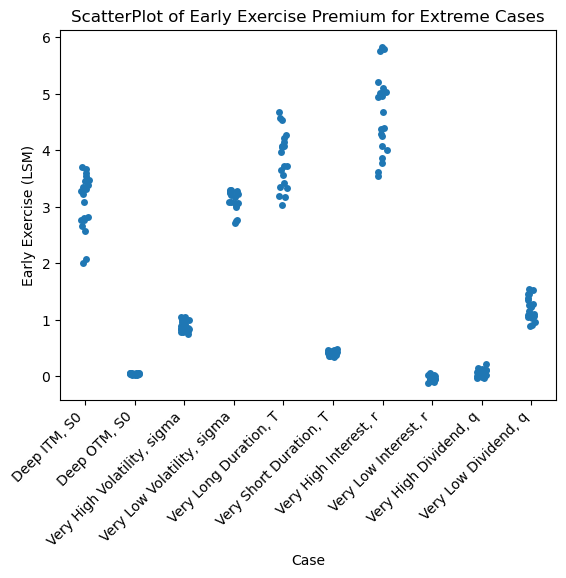

In [ ]:
sns.stripplot(data = edge_results, x = "Case", y = "Early Exercise (LSM)", dodge = True)
plt.xticks(rotation=45, ha='right')
plt.title("ScatterPlot of Early Exercise Premium for Extreme Cases")